# Python Data Analysis for Botanists 🌿

This notebook teaches data analysis using a small **plant growth experiment**.

You will work with measurements that feel familiar to a botanist:

- species and treatment groups
- plant height and leaf size
- chlorophyll index
- soil pH
- water and light exposure
- flower count and biomass
- plant health status

### Learning goals

By the end, you should be able to:

1. Load a CSV file with Pandas
2. Inspect and understand a dataset
3. Select rows and columns
4. Find and handle missing values
5. Detect duplicate observations
6. Calculate descriptive statistics
7. Compare experimental groups
8. Create new biological variables
9. Visualize plant data
10. Examine relationships between measurements
11. Answer simple biological questions using data

> **Teaching note:** The dataset intentionally contains a few missing values and duplicate rows so that data-cleaning steps can be demonstrated.


## 1. Import the tools

We will use:

- **Pandas** for tables and analysis
- **Matplotlib** for plotting
- **Seaborn** for statistical visualizations


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")


### Why we begin by importing libraries

Python on its own knows nothing about tables, statistics, or graphs. That functionality lives in separate **libraries** (also called packages) that must be loaded into memory before the notebook can use them. Placing the imports in the very first code cell is a widely followed convention: a reader can see at a glance which tools the analysis depends on, and every later cell can assume they are available.

Three libraries carry almost all of the work in this notebook.

**pandas** provides the `DataFrame`, a two-dimensional table in which each row is one plant (one *observation*) and each column is one recorded variable (species, height, soil pH, and so on). This is the same mental model as a spreadsheet, but pandas lets us filter, sort, group, summarise, and combine tables with a single line of code and without altering the original file. Almost every analytical step below is a `DataFrame` method.

**matplotlib** is the foundational plotting library. We use it directly for simple figures such as histograms and bar charts, and it also acts as the drawing engine underneath Seaborn. The command `%matplotlib inline` tells Jupyter to display each figure directly beneath the cell that produced it.

**seaborn** is built on top of matplotlib and specialises in statistical graphics. It draws box plots, grouped scatter plots, and heatmaps with far less code than raw matplotlib, and it handles grouping by a categorical variable (such as treatment) automatically. The call `sns.set_theme(style="whitegrid")` fixes a consistent visual style for every figure so the notebook looks uniform.

The standard abbreviations `pd`, `plt`, and `sns` are used almost universally in the scientific Python community; keeping them makes your code readable to others.

## 2. Load the plant dataset

Keep `botany_plant_growth_data.csv` in the same folder as this notebook.


In [2]:
df = pd.read_csv("botany_plant_growth_data.csv")
df.head()


,Plant_ID,Species,Treatment,Site,Soil_Type,Sampling_Date,Light_Hours,Water_ml_per_day,Soil_pH,Leaf_Length_cm,Leaf_Width_cm,Plant_Height_cm,Chlorophyll_Index,Flower_Count,Biomass_g,Health_Status
0,P001,Arabidopsis thaliana,Control,Greenhouse B,Loam,2026-06-26,12.9,256.8,6.18,3.8,1.5,21.9,33.8,8,7.3,Healthy
1,P002,Phaseolus vulgaris,Low Nitrogen,Greenhouse B,Clay Loam,2026-06-14,10.0,202.7,7.49,7.2,5.4,43.8,37.7,6,33.7,Moderate
2,P003,Arabidopsis thaliana,Low Nitrogen,Greenhouse B,Sandy Loam,2026-06-25,8.8,213.9,6.53,3.4,1.5,19.8,32.0,11,6.8,Moderate
3,P004,Arabidopsis thaliana,Control,Greenhouse A,Sandy Loam,2026-07-05,13.4,219.3,6.52,4.6,2.0,26.6,36.4,12,8.2,Healthy
4,P005,Arabidopsis thaliana,High Nitrogen,Greenhouse A,Clay Loam,2026-06-05,9.6,268.0,5.61,4.3,1.9,24.1,36.4,10,8.6,Healthy


### Why we load the data into a DataFrame

The measurements were recorded in a **comma-separated values (CSV)** file: plain text in which each line is one plant and commas separate the fields. `pd.read_csv` reads that file and converts it into a pandas `DataFrame` held in the computer's memory under the name `df`.

Working from the `DataFrame` rather than from the spreadsheet itself has three advantages that matter for scientific work:

1. **The raw file is never modified.** Every cleaning or transformation step acts on the in-memory copy. If we make a mistake, we simply re-run the notebook from this cell and start again from pristine data.
2. **The analysis is reproducible.** Anyone with the same CSV file and this notebook obtains exactly the same results. Manual edits in a spreadsheet leave no record and cannot be reproduced.
3. **The full history is visible.** Each step is written out as code, so a reviewer can see precisely how the numbers in the final conclusion were produced.

Calling `df.head()` immediately afterwards displays the first five rows. This is a deliberate checkpoint, not decoration. We confirm that:

- the columns were separated correctly, so each value sits under the right header;
- text columns contain text and numeric columns contain numbers;
- the magnitudes are biologically sensible — leaf lengths of a few centimetres, plant heights in the tens of centimetres, soil pH near neutral, dates within the sampling period.

If any of these looks wrong, the fault lies in how the file was read and must be fixed here; otherwise every later result inherits the error.

## 3. First look at the data

Before doing any analysis, ask:

- How many observations are there?
- What variables were recorded?
- Which columns are numbers?
- Are any values missing?


### Why we inspect the dataset before analysing it

A dataset should be understood before it is used. These three commands answer the questions every analyst asks first, and together they decide whether the data are fit for the analysis we intend.

**`df.shape` and the column list — how much data, and which variables?**
`df.shape` reports the number of rows and columns — here `(152, 16)`, meaning 152 plant records described by 16 variables. The row count is the sample size behind every mean, count, and correlation we will calculate; a difference between two treatment groups means something different when each group has 40 plants than when one has 3. Printing `df.columns` lists the recorded variables, so we know exactly what the experiment measured and can plan which columns each question needs.

**`df.info()` — what type is each column, and where are values missing?**
For every column this shows the *data type* pandas assigned and the *non-null count*. Both are essential.

- If a column of numbers was accidentally read as text (`object`), arithmetic on it will fail or give nonsense. `info()` is where that is caught.
- The non-null count reveals missing data. Here `Soil_pH` has 149 of 152 values, `Leaf_Width_cm` has 150, and `Chlorophyll_Index` has 148. Missing values are normal in biological work — a probe fails, a sample is lost, a reading is skipped — but we must know where they are, because most calculations either drop those rows silently or raise an error.

**`df.describe()` — what is the range and spread of each measurement?**
This gives the count, mean, standard deviation, minimum, quartiles, and maximum for every numeric column. Its main purpose at this stage is quality control:

- **Impossible values** stand out — a negative height, a pH of 14, a leaf longer than the whole plant.
- **Extreme outliers** appear as a maximum far above the 75th percentile. For example, `Leaf_Length_cm` has a 75th percentile near 11.7 cm but a maximum of 50.5 cm, worth checking before it distorts a group mean.
- **Spread matters biologically.** The standard deviation and the gap between quartiles show how variable a trait is. A treatment mean is only informative alongside the variation around it, which is why we never stop at the mean alone.

In [3]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Rows and columns: (152, 16)

Column names:
['Plant_ID', 'Species', 'Treatment', 'Site', 'Soil_Type', 'Sampling_Date', 'Light_Hours', 'Water_ml_per_day', 'Soil_pH', 'Leaf_Length_cm', 'Leaf_Width_cm', 'Plant_Height_cm', 'Chlorophyll_Index', 'Flower_Count', 'Biomass_g', 'Health_Status']


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Plant_ID           152 non-null    object 
 1   Species            152 non-null    object 
 2   Treatment          152 non-null    object 
 3   Site               152 non-null    object 
 4   Soil_Type          152 non-null    object 
 5   Sampling_Date      152 non-null    object 
 6   Light_Hours        152 non-null    float64
 7   Water_ml_per_day   152 non-null    float64
 8   Soil_pH            149 non-null    float64
 9   Leaf_Length_cm     152 non-null    float64
 10  Leaf_Width_cm      150 non-null    float64
 11  Plant_Height_cm    152 non-null    float64
 12  Chlorophyll_Index  148 non-null    float64
 13  Flower_Count       152 non-null    int64  
 14  Biomass_g          152 non-null    float64
 15  Health_Status      152 non-null    object 
dtypes: float64(8), int64(1), o

In [4]:
df.describe()


,Light_Hours,Water_ml_per_day,Soil_pH,Leaf_Length_cm,Leaf_Width_cm,Plant_Height_cm,Chlorophyll_Index,Flower_Count,Biomass_g
count,152.000000,152.000000,149.000000,152.000000,150.000000,152.000000,148.000000,152.000000,152.000000
mean,10.437500,234.294737,6.592483,12.951316,4.758000,54.845395,42.402703,6.756579,45.293421
std,1.543103,55.325040,0.456659,12.719469,2.059689,27.549130,5.378882,3.036198,30.186122
min,6.100000,69.200000,5.340000,2.900000,1.200000,17.200000,30.400000,1.000000,5.900000
25%,9.500000,220.500000,6.300000,6.075000,3.300000,34.825000,38.100000,5.000000,23.500000
50%,10.600000,248.800000,6.600000,7.900000,4.800000,47.200000,42.900000,7.000000,37.850000
75%,11.425000,269.525000,6.900000,11.650000,6.275000,71.100000,46.300000,9.000000,67.850000
max,14.000000,330.400000,7.700000,50.500000,9.500000,129.700000,52.600000,13.000000,126.900000


### Botanical interpretation

`df.describe()` gives a quick numerical summary.

For example:

- mean plant height
- minimum and maximum soil pH
- average chlorophyll index
- variation in biomass
- range of flower counts

For biological data, don't stop at the mean. The **spread**, unusual values, and experimental groups often matter just as much.


## 4. Selecting columns

### Why we select specific columns

A `DataFrame` can hold dozens of variables, but any single biological question involves only a few. Column selection is the act of stating which variables the current question is about.

`df["Species"]` returns one column as a **Series** (a single labelled vector). `df[["Species", "Treatment", "Plant_Height_cm", "Biomass_g"]]` returns a new, smaller `DataFrame` containing only the listed columns, in the order given. Note the double brackets: the inner `[...]` is an ordinary Python list of column names.

Selecting is worth doing for several reasons:

1. **Readability.** A four-column table can be read at a glance; a sixteen-column table wraps across the screen and buries the comparison you care about.
2. **Intent.** Writing the column list forces you to decide explicitly which measurements bear on the question. "How does treatment relate to height and biomass?" becomes the concrete selection above.
3. **Efficiency and safety.** Later operations run on less data, and you cannot accidentally summarise or plot a variable you did not mean to include.

Selection does not change `df`; it produces a view or copy, leaving the full dataset intact for the next question.

In [5]:
df["Species"].head()


0    Arabidopsis thaliana
1      Phaseolus vulgaris
2    Arabidopsis thaliana
3    Arabidopsis thaliana
4    Arabidopsis thaliana
Name: Species, dtype: object

In [6]:
df[["Species", "Treatment", "Plant_Height_cm", "Biomass_g"]].head()


,Species,Treatment,Plant_Height_cm,Biomass_g
0,Arabidopsis thaliana,Control,21.9,7.3
1,Phaseolus vulgaris,Low Nitrogen,43.8,33.7
2,Arabidopsis thaliana,Low Nitrogen,19.8,6.8
3,Arabidopsis thaliana,Control,26.6,8.2
4,Arabidopsis thaliana,High Nitrogen,24.1,8.6


## 5. Filtering observations

### Why we filter rows

Filtering (also called *subsetting*) keeps only the rows that satisfy a stated condition. Where column selection chooses *variables*, filtering chooses *observations* — the particular plants a question concerns.

The mechanism is a **Boolean mask**. An expression such as `df["Plant_Height_cm"] > 80` produces a column of `True`/`False` values, one per plant. Passing that mask back into `df[...]` returns only the rows marked `True`.

The three examples illustrate three common uses:

- **A threshold on one variable — `df[df["Plant_Height_cm"] > 80]`.** This isolates the tallest plants so we can ask whether they are genuine or data-entry errors, and see which species and treatments they belong to. They turn out to be almost all *Zea mays* under high nitrogen, which is biologically reasonable.
- **One category — `df[df["Treatment"] == "Drought"]`.** This extracts a single experimental group so its measurements and health status can be examined and later compared with the others.
- **A combination of conditions — `(df["Species"] == "Solanum lycopersicum") & (df["Treatment"] == "Drought")`.** The `&` operator combines masks so that *both* must hold. This narrows the data to one cell of the experimental design: drought-stressed tomatoes. Treatment effects are ultimately interpreted at this species-by-treatment level, because species differ so much in baseline size.

Two syntax points: each condition must be wrapped in parentheses when combined, and we use `&` and `|` rather than the words `and` and `or` because the comparison is applied element by element down the column.

In [7]:
# Plants taller than 80 cm
df[df["Plant_Height_cm"] > 80].head()


,Plant_ID,Species,Treatment,Site,Soil_Type,Sampling_Date,Light_Hours,Water_ml_per_day,Soil_pH,Leaf_Length_cm,Leaf_Width_cm,Plant_Height_cm,Chlorophyll_Index,Flower_Count,Biomass_g,Health_Status
7,P008,Zea mays,High Nitrogen,Greenhouse B,Sandy Loam,2026-07-05,9.1,258.1,6.31,47.0,6.0,114.7,51.1,2,97.0,Healthy
20,P021,Solanum lycopersicum,High Nitrogen,Field Plot 1,Clay Loam,2026-06-27,10.6,316.0,NaN,13.8,8.6,91.0,44.8,10,85.0,Healthy
25,P026,Zea mays,Control,Greenhouse B,Sandy Loam,2026-07-06,9.6,300.2,7.35,37.1,4.6,97.7,49.0,2,99.1,Healthy
26,P027,Solanum lycopersicum,High Nitrogen,Greenhouse B,Clay Loam,2026-07-11,10.3,300.8,6.81,13.7,9.5,89.2,45.7,11,74.6,Healthy
27,P028,Zea mays,High Nitrogen,Field Plot 1,Loam,2026-06-26,9.0,265.4,6.99,46.8,5.1,111.7,52.6,2,105.1,Healthy


In [8]:
# Plants under drought treatment
drought = df[df["Treatment"] == "Drought"]
drought.head()


,Plant_ID,Species,Treatment,Site,Soil_Type,Sampling_Date,Light_Hours,Water_ml_per_day,Soil_pH,Leaf_Length_cm,Leaf_Width_cm,Plant_Height_cm,Chlorophyll_Index,Flower_Count,Biomass_g,Health_Status
11,P012,Ocimum basilicum,Drought,Field Plot 1,Clay Loam,2026-07-14,10.9,137.8,6.97,5.4,2.9,31.1,42.1,4,18.9,Stressed
15,P016,Phaseolus vulgaris,Drought,Greenhouse A,Loam,2026-07-29,11.4,128.3,7.05,6.3,4.3,37.1,43.4,4,34.3,Stressed
24,P025,Ocimum basilicum,Drought,Greenhouse A,Sandy Loam,2026-06-05,10.9,160.3,6.09,5.4,3.0,30.2,40.8,4,21.5,Stressed
31,P032,Ocimum basilicum,Drought,Field Plot 1,Loam,2026-06-14,7.5,90.2,6.86,4.7,NaN,26.5,41.5,5,16.1,Stressed
33,P034,Phaseolus vulgaris,Drought,Field Plot 1,Sandy Loam,2026-08-06,11.4,113.7,6.10,7.7,5.3,43.0,42.7,6,33.4,Stressed


In [9]:
# Tomato plants under drought treatment
tomato_drought = df[
    (df["Species"] == "Solanum lycopersicum") &
    (df["Treatment"] == "Drought")
]

tomato_drought.head()


,Plant_ID,Species,Treatment,Site,Soil_Type,Sampling_Date,Light_Hours,Water_ml_per_day,Soil_pH,Leaf_Length_cm,Leaf_Width_cm,Plant_Height_cm,Chlorophyll_Index,Flower_Count,Biomass_g,Health_Status
98,P099,Solanum lycopersicum,Drought,Field Plot 1,Clay Loam,2026-08-07,11.8,93.8,6.96,8.8,5.5,52.5,48.0,7,52.3,Stressed
100,P101,Solanum lycopersicum,Drought,Greenhouse A,Clay Loam,2026-06-22,7.7,126.2,6.69,7.9,4.5,47.7,46.3,7,40.5,Stressed
112,P113,Solanum lycopersicum,Drought,Field Plot 1,Sandy Loam,2026-07-27,11.5,149.9,6.85,7.8,5.3,52.0,45.9,6,49.2,Stressed
125,P126,Solanum lycopersicum,Drought,Field Plot 1,Sandy Loam,2026-07-29,10.8,124.1,6.85,9.3,6.1,58.2,47.0,7,48.4,Stressed


## 6. Missing values

Missing observations are common in biological experiments.

A sensor may fail, a measurement may be skipped, or a sample may be damaged.


### Why we identify and handle missing values

Missing data are the rule, not the exception, in field and greenhouse biology: an instrument fails, a leaf is damaged before it can be measured, a label becomes unreadable, a technician is called away. Before any summary is trusted, two questions must be answered — *how much is missing, and where?*

**Detecting — `df.isna().sum()`.** `isna()` returns a table of `True`/`False` marking every missing cell; summing each column counts them. Here the gaps are confined to `Soil_pH` (3), `Leaf_Width_cm` (2), and `Chlorophyll_Index` (4). This matters because pandas treats missing values inconsistently across operations — `mean()` skips them, some plotting functions drop the whole row, and merges or model fits may fail outright — so an unnoticed gap can quietly change a result.

**Deciding what to do.** There are three broad options: leave the gaps and let each calculation drop them; remove any plant that has a missing value; or *impute* — fill each gap with an estimate. Removing rows discards the other fifteen good measurements on that plant and can bias the sample if the values are not missing at random. Here we impute.

**Imputing with the median — `fillna(df[col].median())`.** The median is the middle value when the data are sorted. It is preferred over the mean for filling because it is *robust*: a handful of unusually tall maize plants pull the mean upward but barely move the median, so median imputation is less likely to distort the column.

**The essential caveat.** Median imputation is a reasonable teaching default, but in real research the correct treatment depends on *why* the value is missing. If chlorophyll readings failed only on the darkest leaves, filling with the median would erase a real pattern. Imputation also makes the data look more certain than they are, because the filled values carry no measurement error. Always report how many values were missing and how they were handled.

In [10]:
df.isna().sum()


Plant_ID             0
Species              0
Treatment            0
Site                 0
Soil_Type            0
Sampling_Date        0
Light_Hours          0
Water_ml_per_day     0
Soil_pH              3
Leaf_Length_cm       0
Leaf_Width_cm        2
Plant_Height_cm      0
Chlorophyll_Index    4
Flower_Count         0
Biomass_g            0
Health_Status        0
dtype: int64

In [11]:
# Example: fill missing chlorophyll values with the median
df["Chlorophyll_Index"] = df["Chlorophyll_Index"].fillna(
    df["Chlorophyll_Index"].median()
)

# Example: fill missing soil pH with the median
df["Soil_pH"] = df["Soil_pH"].fillna(df["Soil_pH"].median())

# Example: fill missing leaf width with the median
df["Leaf_Width_cm"] = df["Leaf_Width_cm"].fillna(
    df["Leaf_Width_cm"].median()
)

df.isna().sum()


Plant_ID             0
Species              0
Treatment            0
Site                 0
Soil_Type            0
Sampling_Date        0
Light_Hours          0
Water_ml_per_day     0
Soil_pH              0
Leaf_Length_cm       0
Leaf_Width_cm        0
Plant_Height_cm      0
Chlorophyll_Index    0
Flower_Count         0
Biomass_g            0
Health_Status        0
dtype: int64

### Why median?

The median is less sensitive to unusually large or small values than the mean.

In a real experiment, the correct treatment of missing data depends on **why the value is missing**. Filling with the median is useful here for teaching, but shouldn't be applied blindly to research data.


## 7. Detect duplicate observations

### Why we check for duplicate rows

A **duplicate** is a single plant that has been entered into the table more than once — commonly from merging spreadsheets, re-exporting data, or a copy-and-paste slip. Duplicates are dangerous precisely because they are invisible in a summary: a plant recorded twice is counted twice in every mean, every category count, and every point on every plot, silently pulling results toward whatever that one individual measured.

**Detecting — `df.duplicated().sum()`.** `duplicated()` marks a row `True` if every one of its values has already appeared, in the same combination, in an earlier row. Summing counts them; here there are 2.

**Inspecting before deleting — `df[df.duplicated(keep=False)]`.** The argument `keep=False` marks *every* copy, not just the later repeats, so we can view the full groups side by side (sorted by `Plant_ID`). This is a deliberate check: we confirm that the rows match in every column — same ID, same site, same measurements — and are therefore true duplicates, not two genuine plants that happen to share a few values.

**Removing — `df.drop_duplicates()`.** Once confirmed, this keeps the first occurrence of each row and discards the rest. The shape drops from 152 to 150, and each plant now contributes exactly once. Adding `.copy()` makes `df` a clean, independent table and avoids later `SettingWithCopyWarning` messages.

In [12]:
print("Duplicate rows:", df.duplicated().sum())

df[df.duplicated(keep=False)].sort_values("Plant_ID")


Duplicate rows: 2


,Plant_ID,Species,Treatment,Site,Soil_Type,Sampling_Date,Light_Hours,Water_ml_per_day,Soil_pH,Leaf_Length_cm,Leaf_Width_cm,Plant_Height_cm,Chlorophyll_Index,Flower_Count,Biomass_g,Health_Status
14,P015,Arabidopsis thaliana,Low Nitrogen,Greenhouse B,Loam,2026-06-07,11.5,250.1,6.15,3.0,1.4,18.1,30.6,9,6.5,Moderate
150,P015,Arabidopsis thaliana,Low Nitrogen,Greenhouse B,Loam,2026-06-07,11.5,250.1,6.15,3.0,1.4,18.1,30.6,9,6.5,Moderate
92,P093,Solanum lycopersicum,Low Nitrogen,Field Plot 1,Loam,2026-07-28,11.3,251.2,6.80,10.6,6.2,64.5,42.7,9,59.5,Moderate
151,P093,Solanum lycopersicum,Low Nitrogen,Field Plot 1,Loam,2026-07-28,11.3,251.2,6.80,10.6,6.2,64.5,42.7,9,59.5,Moderate


In [13]:
# Remove exact duplicate rows
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (150, 16)


## 8. Counting categories

### Why we count categories before comparing groups

Before comparing treatment or species groups, we need to know how the plants are distributed among them. A group mean is only as reliable as the number of plants behind it, and comparisons are cleanest when the groups are of similar size (a *balanced* design).

**`value_counts()`** tallies how many plants fall in each level of a categorical variable — here 37 *Ocimum basilicum*, 36 *Solanum lycopersicum*, and so on for species, and 55 Control, 38 High Nitrogen, 34 Low Nitrogen, 23 Drought for treatment. Already we can see the treatments are not equally represented.

**`pd.crosstab(df["Species"], df["Treatment"])`** cross-tabulates the two variables, giving the count for every species-by-treatment combination. This is the picture that matters for interpretation. It shows, for instance, that only **one** *Arabidopsis thaliana* plant received the drought treatment. Any "mean" for that cell is a single measurement with no estimate of variability, and any conclusion drawn from it would be unsound. Knowing this now prevents over-interpreting a sparse cell later.

A cross-tabulation also reveals whether the design is *complete* — whether every combination was actually planted — which determines which comparisons are possible at all.

In [14]:
df["Species"].value_counts()


Species
Ocimum basilicum        37
Solanum lycopersicum    36
Phaseolus vulgaris      28
Arabidopsis thaliana    25
Zea mays                24
Name: count, dtype: int64

In [15]:
df["Treatment"].value_counts()


Treatment
Control          55
High Nitrogen    38
Low Nitrogen     34
Drought          23
Name: count, dtype: int64

In [16]:
pd.crosstab(df["Species"], df["Treatment"])


Treatment,Control,Drought,High Nitrogen,Low Nitrogen
Species,,,,
Arabidopsis thaliana,14,1,6,4
Ocimum basilicum,13,7,9,8
Phaseolus vulgaris,6,5,7,10
Solanum lycopersicum,13,4,10,9
Zea mays,9,6,6,3


## 9. Compare treatment groups with `groupby`

This is one of the most useful operations in experimental biology.


### Why we use `groupby` to compare treatments

The central question of the experiment is whether the treatments change how the plants grow, and `groupby` is the tool that answers it. It follows a three-part pattern often called **split–apply–combine**: *split* the 150 plants into groups by a categorical variable, *apply* a summary function (here `mean`) to each group, and *combine* the results into a compact table with one row per group.

**`df.groupby("Treatment")[[...]].mean()`** produces the mean height, chlorophyll index, and biomass for each of the four treatments, side by side. Reading down a column compares the treatments directly; we can see, for example, that mean biomass under High Nitrogen (55.1 g) is well above Control (44.8 g), while Low Nitrogen (38.6 g) sits below it.

**`df.groupby(["Species", "Treatment"])["Plant_Height_cm"].mean()`** groups by two variables at once. This is important because the species differ enormously in size — maize towers over *Arabidopsis* — so a treatment effect averaged across all species could be driven by one species alone, or hidden by species responding in opposite directions. Grouping by species *and* treatment lets us check whether the pattern is consistent. Here every species is tallest under High Nitrogen and shortest under Drought or Low Nitrogen, which is stronger evidence than the pooled figure.

**`df.groupby("Treatment")["Biomass_g"].mean().sort_values(ascending=False)`** answers a specific question — which treatment gives the greatest mean biomass — by ordering the result rather than making the reader scan the table.

`groupby` still only *describes* the sample. Whether these differences reflect a real effect of treatment is a question for experimental design and statistical testing, addressed in the caution at the end of the notebook.

In [17]:
df.groupby("Treatment")[
    ["Plant_Height_cm", "Chlorophyll_Index", "Biomass_g"]
].mean().round(2)


,Plant_Height_cm,Chlorophyll_Index,Biomass_g
Treatment,,,
Control,55.00,42.89,44.81
Drought,48.16,44.78,41.22
High Nitrogen,66.35,43.89,55.09
Low Nitrogen,47.06,38.74,38.60


In [18]:
df.groupby(["Species", "Treatment"])["Plant_Height_cm"].mean().round(2)


Species               Treatment    
Arabidopsis thaliana  Control           22.47
                      Drought           17.20
                      High Nitrogen     25.13
                      Low Nitrogen      18.65
Ocimum basilicum      Control           39.48
                      Drought           28.73
                      High Nitrogen     43.86
                      Low Nitrogen      34.05
Phaseolus vulgaris    Control           52.92
                      Drought           40.54
                      High Nitrogen     60.21
                      Low Nitrogen      43.80
Solanum lycopersicum  Control           71.65
                      Drought           52.60
                      High Nitrogen     82.25
                      Low Nitrogen      59.39
Zea mays              Control          105.37
                      Drought           79.37
                      High Nitrogen    121.95
                      Low Nitrogen      93.50
Name: Plant_Height_cm, dtype: float64

### Question

Which treatment has the highest mean biomass?


In [19]:
df.groupby("Treatment")["Biomass_g"].mean().sort_values(ascending=False)


Treatment
High Nitrogen    55.092105
Control          44.810909
Drought          41.221739
Low Nitrogen     38.600000
Name: Biomass_g, dtype: float64

## 10. Create biologically useful derived variables

A dataset often becomes more useful after creating new measurements from existing columns.

Here we calculate an approximate leaf area using:

**Leaf area ≈ leaf length × leaf width**


### Why we create derived variables

Not every biologically meaningful quantity is measured directly. Often the informative variable is a *combination* of two or more recorded ones. Computing it as a new column — sometimes called **feature engineering** — lets it be summarised, grouped, sorted, and correlated exactly like a measured trait.

**Approximate leaf area — `Leaf_Length_cm * Leaf_Width_cm`.** Length and width each describe only one dimension of the leaf. Their product approximates leaf area, which is more directly tied to the leaf's function: light interception and photosynthetic capacity. It is an approximation because it treats the leaf as a rectangle; precise work multiplies by a species-specific shape correction factor.

**Water-use efficiency — `Biomass_g / Water_ml_per_day * 100`.** This expresses biomass produced per 100 mL of water supplied each day. It converts two separate numbers into the single quantity a drought or irrigation study actually cares about: how effectively each plant turns water into growth. Two plants with the same biomass but very different water inputs are not equivalent, and this index makes that difference explicit.

Because these are ordinary columns once created, the rest of the notebook can treat them as first-class measurements — for example, ranking plants by leaf area, or including efficiency in the correlation matrix.

In [20]:
df["Approx_Leaf_Area_cm2"] = (
    df["Leaf_Length_cm"] * df["Leaf_Width_cm"]
)

df[[
    "Species",
    "Leaf_Length_cm",
    "Leaf_Width_cm",
    "Approx_Leaf_Area_cm2"
]].head()


,Species,Leaf_Length_cm,Leaf_Width_cm,Approx_Leaf_Area_cm2
0,Arabidopsis thaliana,3.8,1.5,5.70
1,Phaseolus vulgaris,7.2,5.4,38.88
2,Arabidopsis thaliana,3.4,1.5,5.10
3,Arabidopsis thaliana,4.6,2.0,9.20
4,Arabidopsis thaliana,4.3,1.9,8.17


In [21]:
# Biomass produced per 100 mL of daily water
df["Biomass_per_100ml_Water"] = (
    df["Biomass_g"] / df["Water_ml_per_day"] * 100
)

df[["Species", "Treatment", "Biomass_per_100ml_Water"]].head()


,Species,Treatment,Biomass_per_100ml_Water
0,Arabidopsis thaliana,Control,2.842679
1,Phaseolus vulgaris,Low Nitrogen,16.625555
2,Arabidopsis thaliana,Low Nitrogen,3.179056
3,Arabidopsis thaliana,Control,3.739170
4,Arabidopsis thaliana,High Nitrogen,3.208955


## 11. Sorting and finding extreme observations

### Why we look at the largest and smallest values

Extreme observations are informative in two different ways: they can be errors to correct, or they can be the biological signal itself. Sorting the data to the top and bottom of a variable brings both to attention.

**`df.nlargest(10, "Plant_Height_cm")`** returns the ten tallest plants with their species and treatment. This is a final data check — a value far above everything else may be a typo, such as a misplaced decimal point or a wrong unit — and also a first result: the tallest plants are almost all *Zea mays* under High Nitrogen, consistent with maize being a large C4 grass that responds strongly to nitrogen supply.

**`df.nsmallest(10, "Chlorophyll_Index")`** returns the ten least-green plants. Low chlorophyll is a classic visible symptom of stress or nutrient deficiency, particularly nitrogen shortage, because nitrogen is a major structural component of the chlorophyll molecule. The list is dominated by *Arabidopsis thaliana* under Low Nitrogen — exactly the pattern biology predicts, and therefore a meaningful finding rather than noise.

Looking at extremes is quick, requires no statistical assumptions, and often points to the plants or comparisons worth studying in detail.

In [22]:
df.nlargest(
    10,
    "Plant_Height_cm"
)[["Plant_ID", "Species", "Treatment", "Plant_Height_cm"]]


,Plant_ID,Species,Treatment,Plant_Height_cm
34,P035,Zea mays,High Nitrogen,129.7
136,P137,Zea mays,High Nitrogen,129.7
115,P116,Zea mays,High Nitrogen,125.7
138,P139,Zea mays,High Nitrogen,120.2
7,P008,Zea mays,High Nitrogen,114.7
27,P028,Zea mays,High Nitrogen,111.7
147,P148,Zea mays,Control,109.7
106,P107,Zea mays,Control,108.3
54,P055,Zea mays,Control,107.7
143,P144,Zea mays,Control,107.7


In [23]:
df.nsmallest(
    10,
    "Chlorophyll_Index"
)[["Plant_ID", "Species", "Treatment", "Chlorophyll_Index"]]


,Plant_ID,Species,Treatment,Chlorophyll_Index
80,P081,Arabidopsis thaliana,Low Nitrogen,30.4
14,P015,Arabidopsis thaliana,Low Nitrogen,30.6
2,P003,Arabidopsis thaliana,Low Nitrogen,32.0
19,P020,Arabidopsis thaliana,Low Nitrogen,32.2
45,P046,Arabidopsis thaliana,Control,33.0
48,P049,Arabidopsis thaliana,High Nitrogen,33.0
105,P106,Arabidopsis thaliana,Control,33.0
58,P059,Arabidopsis thaliana,Control,33.4
97,P098,Arabidopsis thaliana,Control,33.5
0,P001,Arabidopsis thaliana,Control,33.8


## 12. Plot 1: Distribution of plant height

### Why we plot the distribution of a variable

A single number such as a mean compresses away the *shape* of the data, and shape carries information a mean cannot. A **histogram** recovers it by dividing the range of a variable into equal intervals ("bins") and drawing a bar whose height is the number of plants that fall in each.

For plant height we are reading the figure for:

- **Symmetry or skew.** A long tail on one side means the mean is pulled away from the typical value, and the median may be the better summary.
- **The number of peaks.** A single hump suggests one homogeneous population. Here the distribution is broad and uneven because the dataset combines small herbs (*Arabidopsis*, basil) with tall species (tomato, maize); the height column is really several biological populations overlaid.
- **Gaps and isolated bars**, which flag outliers or distinct subgroups.

The shape also tells us whether later methods that assume an approximately normal (bell-shaped) distribution are reasonable for this variable, or whether it should be analysed within species rather than pooled.

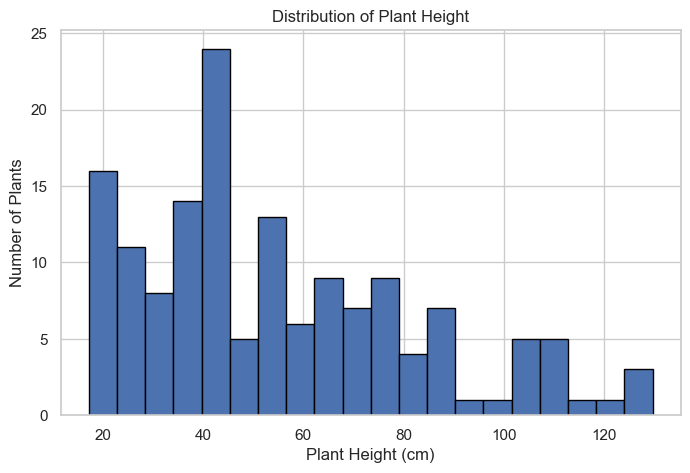

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(df["Plant_Height_cm"], bins=20, edgecolor="black")
plt.xlabel("Plant Height (cm)")
plt.ylabel("Number of Plants")
plt.title("Distribution of Plant Height")
plt.show()


## 13. Plot 2: Mean biomass by treatment

### Why we present group means as a bar chart

The `groupby` table already contains the mean biomass for each treatment. A bar chart adds no new information; it makes the existing information easier to absorb. The length of each bar is proportional to the group mean, so the *ranking* of the treatments and the *size of the gaps* between them register at a glance — much faster than reading four numbers from a table and comparing them mentally.

Sorting the bars by value (`.sort_values()`) before plotting arranges the treatments in order of effect, which is the natural way to read the chart.

A bar of the mean alone has a well-known limitation: it hides how variable the plants within each group are, and two groups with the same mean can have very different spreads. That is exactly why the next section moves to a box plot, which shows the spread as well as the centre.

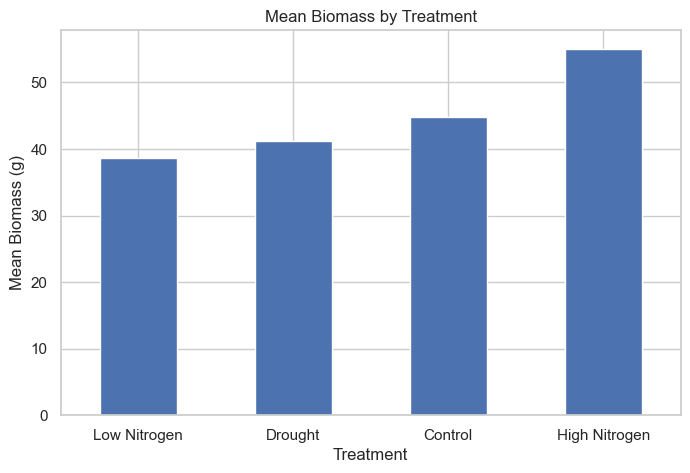

In [25]:
mean_biomass = (
    df.groupby("Treatment")["Biomass_g"]
      .mean()
      .sort_values()
)

mean_biomass.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Mean Biomass (g)")
plt.xlabel("Treatment")
plt.title("Mean Biomass by Treatment")
plt.xticks(rotation=0)
plt.show()


## 14. Plot 3: Compare plant height across treatments

A box plot is useful because it shows:

- median
- spread
- possible outliers
- differences between groups


### Why we use a box plot to compare groups

A **box plot** summarises the whole distribution of a variable within each group, not just its centre. For each treatment: the box spans the interquartile range (the middle 50% of plants), the line inside the box is the median, the "whiskers" reach to the bulk of the remaining data, and individual points beyond them are potential outliers.

This lets us judge something a bar chart cannot: **whether the groups actually separate.** If the boxes for two treatments barely overlap, the difference between them is large relative to the variation within them and is likely to be meaningful. If the boxes overlap heavily, the difference in medians may be small compared with plant-to-plant variability, and we should be cautious about claiming an effect. Overlap is the visual warning sign that a formal statistical test is needed before drawing a conclusion.

The box plot also shows whether a group is skewed (the median sits off-centre in the box) and whether it contains outliers that deserve a second look.

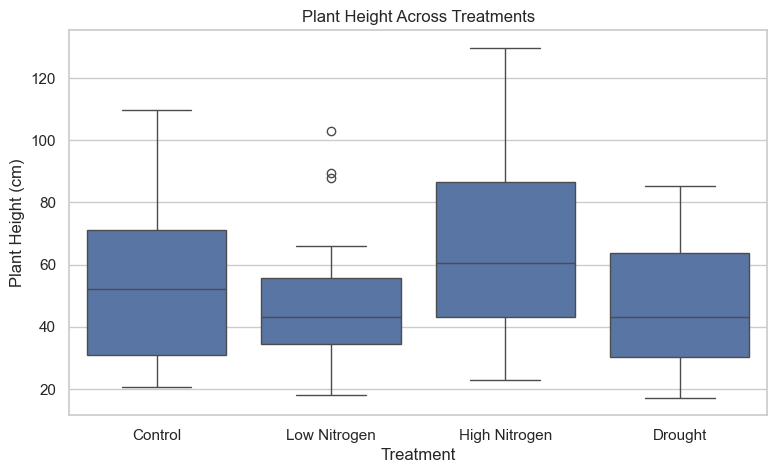

In [26]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Treatment", y="Plant_Height_cm")
plt.title("Plant Height Across Treatments")
plt.xlabel("Treatment")
plt.ylabel("Plant Height (cm)")
plt.show()


## 15. Plot 4: Biomass by species and treatment

### Why we split the comparison by species

When all species are pooled, a real treatment effect can be masked or exaggerated, because the species differ so greatly in size that species identity dominates the variation in biomass. This is a **confounding** problem: a difference we attribute to treatment might actually be a difference in which species happened to end up in each group.

Drawing the box plot with **species on the x-axis and treatment as the colour (`hue`)** removes that confound visually. Within each species we compare the treatment boxes on a like-for-like basis, and across species we compare *how large* the treatment effect is. The figure shows, for instance, that High Nitrogen raises biomass in every species, but the absolute increase is far greater in maize and tomato than in *Arabidopsis* — an **interaction** between species and treatment that the pooled comparison would hide.

Plotting one figure with both factors is more informative, and easier to read, than many separate plots.

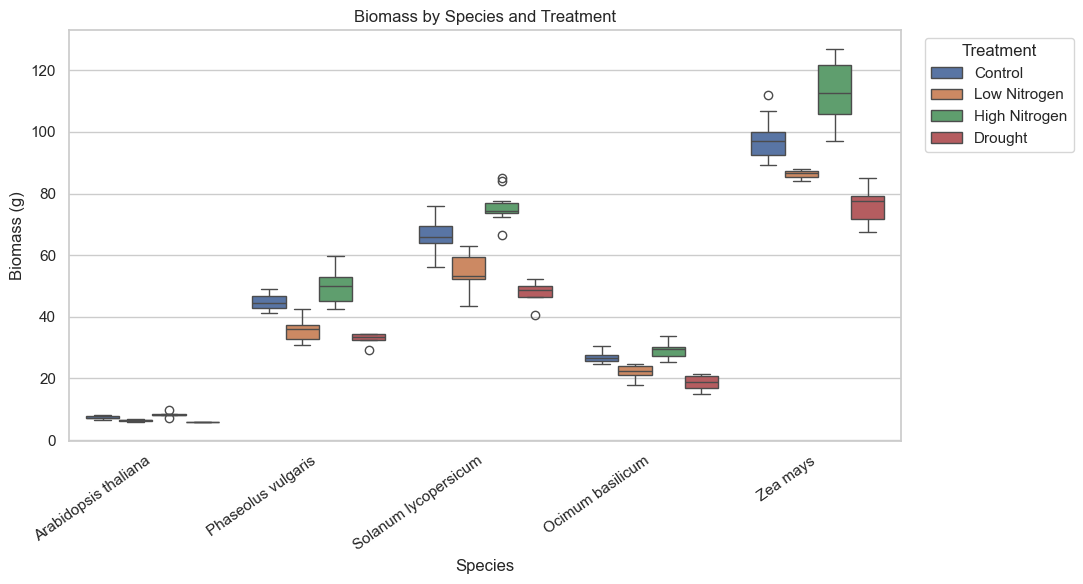

In [27]:
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df,
    x="Species",
    y="Biomass_g",
    hue="Treatment"
)
plt.title("Biomass by Species and Treatment")
plt.xlabel("Species")
plt.ylabel("Biomass (g)")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Treatment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 16. Plot 5: Relationship between water and biomass

Scatter plots help us inspect relationships between two continuous measurements.


### Why we use a scatter plot for two continuous variables

When both variables are continuous measurements, a **scatter plot** is the natural tool: each plant is one point, positioned by its water supply and its biomass. From the cloud of points we read several things at once:

- **Direction** — do plants given more water tend to have more biomass?
- **Form** — is the relationship roughly a straight line, or does it curve or level off (water helping up to a point, then not)?
- **Strength** — do the points hug a trend, or is the scatter wide?
- **Groups** — colouring by treatment shows that the Drought plants form a cluster at the low-water end. This is by design (drought was imposed by restricting water), and it is a reminder that treatment and water supply are not independent in this dataset.

A scatter plot is also the honest companion to the correlation coefficient calculated next: the same correlation value can arise from very different patterns, and only the plot shows which one you actually have.

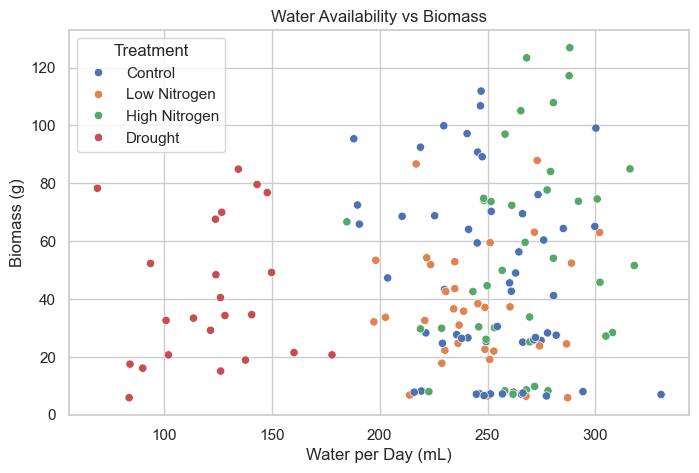

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Water_ml_per_day",
    y="Biomass_g",
    hue="Treatment"
)
plt.title("Water Availability vs Biomass")
plt.xlabel("Water per Day (mL)")
plt.ylabel("Biomass (g)")
plt.show()


## 17. Correlation

Correlation ranges from **-1 to +1**.

- close to +1: both variables tend to increase together
- close to -1: one tends to decrease as the other increases
- close to 0: little linear relationship

Important: **correlation does not prove causation**.


### Why we compute a correlation matrix

We have several continuous traits and want to know which of them vary together. Inspecting every pair with a separate scatter plot would mean dozens of figures; a **correlation matrix** screens all pairs at once.

**What the number means.** The Pearson correlation coefficient, *r*, ranges from −1 to +1. Values near +1 mean the two traits increase together in near-linear fashion; values near −1 mean one rises as the other falls; values near 0 mean little *linear* relationship (a curved relationship could still exist). `df[numeric_columns].corr()` computes *r* for every pair and arranges it in a square table; the diagonal is always 1 because a variable correlates perfectly with itself, and the table is symmetric about that diagonal.

**How to read this one.** Height, approximate leaf area, and biomass are all strongly positively correlated (*r* around 0.9), reflecting overall plant vigour — large plants are large in every dimension. Flower count is negatively correlated with those size traits here, a pattern worth explaining biologically rather than accepting at face value. Some high correlations are *built in*: `Approx_Leaf_Area_cm2` is the product of leaf length and width, so its strong correlation with them is arithmetic, not a discovery.

**The heatmap** (`sns.heatmap`) is the same matrix with colour encoding the value, so strong positive and strong negative pairs stand out immediately without reading numbers.

**The crucial caveat.** Correlation is not causation. Two traits can move together because one drives the other, because a third factor drives both, or by coincidence in a limited sample. A correlation identifies a relationship worth investigating; it does not explain it.

In [29]:
numeric_columns = [
    "Light_Hours",
    "Water_ml_per_day",
    "Soil_pH",
    "Leaf_Length_cm",
    "Leaf_Width_cm",
    "Plant_Height_cm",
    "Chlorophyll_Index",
    "Flower_Count",
    "Biomass_g",
    "Approx_Leaf_Area_cm2"
]

correlation_matrix = df[numeric_columns].corr()
correlation_matrix.round(2)


,Light_Hours,Water_ml_per_day,Soil_pH,Leaf_Length_cm,Leaf_Width_cm,Plant_Height_cm,Chlorophyll_Index,Flower_Count,Biomass_g,Approx_Leaf_Area_cm2
Light_Hours,1.00,0.02,-0.07,-0.07,-0.03,-0.06,-0.11,0.04,-0.09,-0.06
Water_ml_per_day,0.02,1.00,-0.18,0.02,0.16,0.12,-0.16,0.29,0.07,0.11
Soil_pH,-0.07,-0.18,1.00,-0.03,0.02,-0.01,0.06,-0.05,0.03,-0.04
Leaf_Length_cm,-0.07,0.02,-0.03,1.00,0.28,0.88,0.66,-0.67,0.86,0.96
Leaf_Width_cm,-0.03,0.16,0.02,0.28,1.00,0.67,0.65,-0.02,0.69,0.48
Plant_Height_cm,-0.06,0.12,-0.01,0.88,0.67,1.00,0.81,-0.46,0.99,0.95
Chlorophyll_Index,-0.11,-0.16,0.06,0.66,0.65,0.81,1.00,-0.47,0.83,0.70
Flower_Count,0.04,0.29,-0.05,-0.67,-0.02,-0.46,-0.47,1.00,-0.47,-0.54
Biomass_g,-0.09,0.07,0.03,0.86,0.69,0.99,0.83,-0.47,1.00,0.93
Approx_Leaf_Area_cm2,-0.06,0.11,-0.04,0.96,0.48,0.95,0.70,-0.54,0.93,1.00


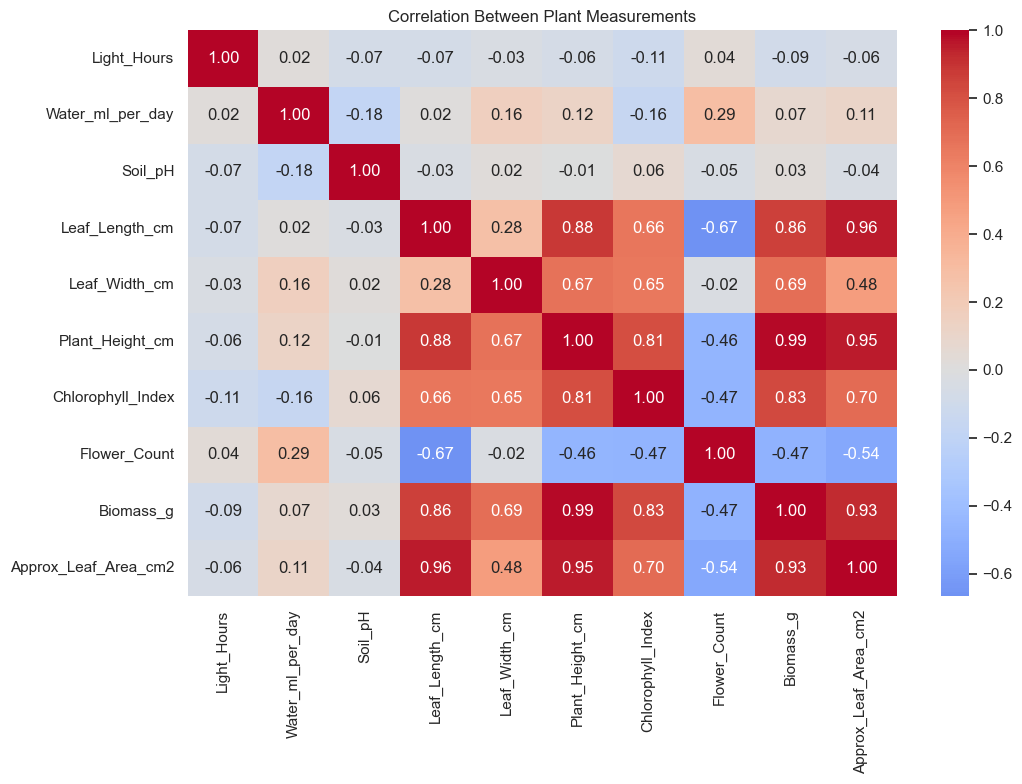

In [30]:
plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Between Plant Measurements")
plt.tight_layout()
plt.show()


## 18. A small botanical investigation

### Question:
Does drought appear to reduce plant height compared with the control group?

We can compare the mean height for each species under the two treatments.


### Why we structure the drought analysis this way

This final section combines the earlier techniques to answer one focused question: *does drought reduce plant height relative to the control?*

**Filter, then group within species.** We first keep only the Control and Drought plants, then compute mean height for each species under each of the two treatments (`groupby(["Species", "Treatment"]).mean().unstack()`). Comparing **within each species** rather than pooling is deliberate: because species differ so much in height, a pooled comparison could be swayed by any imbalance in which species ended up in each treatment group. Within-species comparison removes that confound.

**Quantify the effect.** The `Difference_cm = Control − Drought` column turns the comparison into a single interpretable number per species — how many centimetres of height are lost under drought. Every value is positive, and the loss is larger in the larger species, suggesting a roughly proportional response.

**Visualise it.** The paired bar chart places the Control and Drought means side by side for each species, making the consistent direction of the effect immediately clear.

**The limit of the analysis.** A consistent difference in means across species is suggestive, but it is still description. Establishing that drought *causes* reduced height requires what description cannot provide: randomised assignment, adequate replication in every cell (recall that only one *Arabidopsis* was droughted), controlled conditions, and a statistical test that accounts for natural variability. Data analysis locates and quantifies a pattern; experimental design and statistics are what license a causal conclusion.

In [31]:
control_vs_drought = df[
    df["Treatment"].isin(["Control", "Drought"])
]

comparison = (
    control_vs_drought
    .groupby(["Species", "Treatment"])["Plant_Height_cm"]
    .mean()
    .unstack()
)

comparison["Difference_cm"] = comparison["Control"] - comparison["Drought"]
comparison.round(2)


Treatment,Control,Drought,Difference_cm
Species,,,
Arabidopsis thaliana,22.47,17.20,5.27
Ocimum basilicum,39.48,28.73,10.75
Phaseolus vulgaris,52.92,40.54,12.38
Solanum lycopersicum,71.65,52.60,19.05
Zea mays,105.37,79.37,26.00


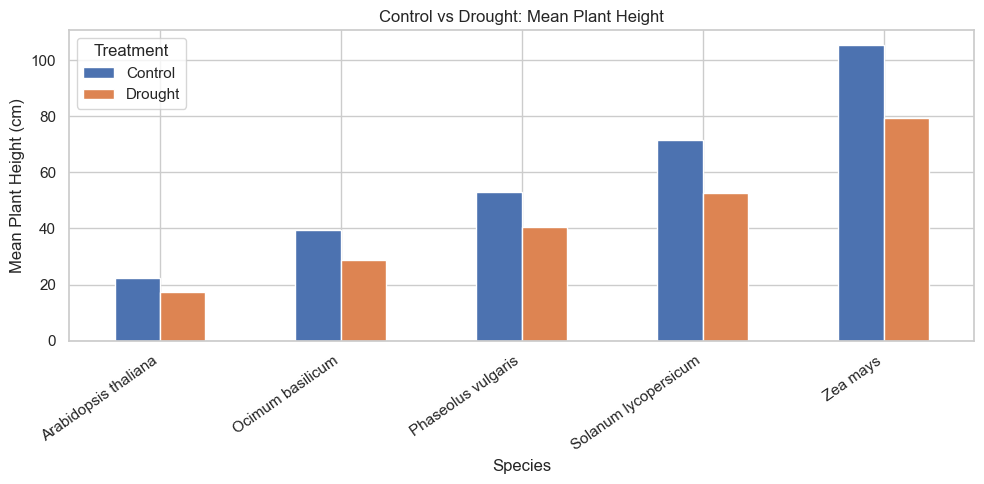

In [32]:
comparison[["Control", "Drought"]].plot(
    kind="bar",
    figsize=(10, 5)
)
plt.ylabel("Mean Plant Height (cm)")
plt.xlabel("Species")
plt.title("Control vs Drought: Mean Plant Height")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 19. Exercise section

Try these before looking at possible solutions.

### Exercise 1
Find all plants with soil pH below 6.0.

### Exercise 2
Calculate the mean chlorophyll index for each species.

### Exercise 3
Which species has the highest average biomass?

### Exercise 4
Count how many plants are marked `Healthy`, `Moderate`, and `Stressed`.

### Exercise 5
Create a scatter plot of `Plant_Height_cm` against `Biomass_g`.

### Exercise 6
Compare mean biomass between `Control` and `High Nitrogen`.

### Exercise 7
Find the five plants with the largest approximate leaf area.


## 20. Exercise solutions

In [34]:
# Exercise 1
df[df["Soil_pH"] < 6.0].head()


,Plant_ID,Species,Treatment,Site,Soil_Type,Sampling_Date,Light_Hours,Water_ml_per_day,Soil_pH,Leaf_Length_cm,Leaf_Width_cm,Plant_Height_cm,Chlorophyll_Index,Flower_Count,Biomass_g,Health_Status,Approx_Leaf_Area_cm2,Biomass_per_100ml_Water
4,P005,Arabidopsis thaliana,High Nitrogen,Greenhouse A,Clay Loam,2026-06-05,9.6,268.0,5.61,4.3,1.9,24.1,36.4,10,8.6,Healthy,8.17,3.208955
64,P065,Solanum lycopersicum,High Nitrogen,Greenhouse B,Clay Loam,2026-07-27,10.6,279.2,5.91,14.6,8.7,88.3,44.7,12,84.1,Healthy,127.02,30.121777
73,P074,Phaseolus vulgaris,Control,Greenhouse A,Clay Loam,2026-06-13,12.0,280.6,5.72,8.9,4.8,52.2,46.4,7,41.2,Healthy,42.72,14.682823
76,P077,Solanum lycopersicum,Control,Greenhouse A,Sandy Loam,2026-08-10,11.1,264.5,5.83,10.3,7.0,65.7,48.6,9,56.3,Healthy,72.10,21.285444
77,P078,Ocimum basilicum,High Nitrogen,Greenhouse A,Sandy Loam,2026-06-15,10.9,218.9,5.82,7.3,4.5,44.1,44.5,8,29.7,Healthy,32.85,13.567839


In [35]:
# Exercise 2
df.groupby("Species")["Chlorophyll_Index"].mean().round(2)


Species
Arabidopsis thaliana    34.32
Ocimum basilicum        41.17
Phaseolus vulgaris      42.10
Solanum lycopersicum    45.42
Zea mays                49.10
Name: Chlorophyll_Index, dtype: float64

In [36]:
# Exercise 3
df.groupby("Species")["Biomass_g"].mean().sort_values(ascending=False)


Species
Zea mays                94.841667
Solanum lycopersicum    63.966667
Phaseolus vulgaris      40.664286
Ocimum basilicum        24.778378
Arabidopsis thaliana     7.368000
Name: Biomass_g, dtype: float64

In [37]:
# Exercise 4
df["Health_Status"].value_counts()


Health_Status
Healthy     93
Moderate    34
Stressed    23
Name: count, dtype: int64

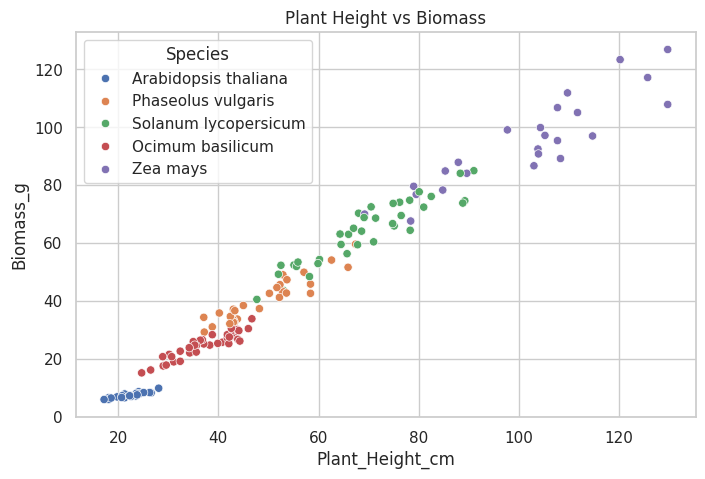

In [38]:
# Exercise 5
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Plant_Height_cm", y="Biomass_g", hue="Species")
plt.title("Plant Height vs Biomass")
plt.show()


In [39]:
# Exercise 6
df[
    df["Treatment"].isin(["Control", "High Nitrogen"])
].groupby("Treatment")["Biomass_g"].mean().round(2)


Treatment
Control          44.81
High Nitrogen    55.09
Name: Biomass_g, dtype: float64

In [40]:
# Exercise 7
df.nlargest(
    5,
    "Approx_Leaf_Area_cm2"
)[[
    "Plant_ID",
    "Species",
    "Approx_Leaf_Area_cm2"
]]


,Plant_ID,Species,Approx_Leaf_Area_cm2
136,P137,Zea mays,329.34
138,P139,Zea mays,313.10
34,P035,Zea mays,305.61
115,P116,Zea mays,285.94
7,P008,Zea mays,282.00


## 21. Take-home mini project

Use the dataset to answer this biological question:

> **How do water availability and nitrogen treatment affect plant growth and biomass across different species?**

Your analysis should include:

1. A short description of the dataset
2. Data-cleaning steps
3. At least three summary statistics
4. At least three plots
5. A comparison of treatment groups
6. One correlation analysis
7. A short biological interpretation in plain language

### Important

Data analysis can show patterns in an experiment. Whether those patterns support a biological conclusion depends on experimental design, replication, controls, statistics, and domain knowledge.


In [1]:
students = {
    "S001": {
        "name": "Arjun",
        "class": "10A",
        "subjects": {
            "Python": [85, 90, 78],
            "Maths": [92, 88, 95],
            "Science": [76, 84, 80]
        }
    },
    "S002": {
        "name": "Meera",
        "class": "10B",
        "subjects": {
            "Python": [95, 91, 89],
            "Maths": [78, 85, 82],
            "Science": [88, 90, 94]
        }
    },
    "S003": {
        "name": "Rahul",
        "class": "10A",
        "subjects": {
            "Python": [72, 80, 75],
            "Maths": [90, 93, 89],
            "Science": [85, 79, 88]
        }
    }
}

In [9]:
for k in [[j[0],j[1]] for j in [list(i.values()) for i in students.values()]] :
    print(k[0],k[1])


Arjun 10A
Meera 10B
Rahul 10A


In [10]:
```# print(Arjun 10A
Meera 10B
Rahul 10A)```

SyntaxError: invalid decimal literal (3989052675.py, line 2)

In [12]:
print('Arjun 10A,Meera 10B,Rahul 10A')

Arjun 10A,Meera 10B,Rahul 10A
